<a href="https://colab.research.google.com/github/stiltnerag/INFO648/blob/main/Assignment_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [5]:
df=pd.read_csv("/content/cps_with_education.csv")
df.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
0,0,2020.0,40.0,0.0,63.0,2.0,23.0,Some College
1,1,2020.0,999.0,0.0,67.0,1.0,23.0,Some College
2,2,2020.0,48.0,654.0,64.0,1.0,23.0,Some College
3,3,2020.0,999.0,0.0,71.0,2.0,23.0,Less than HS
4,4,2020.0,44.0,0.0,54.0,2.0,23.0,Some College


In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1198873 entries, 0 to 1198872
Data columns (total 8 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   Unnamed: 0  1198873 non-null  int64  
 1   YEAR        1198872 non-null  float64
 2   UHRSWORKT   1198872 non-null  float64
 3   EARNWEEK2   1198872 non-null  float64
 4   AGE         1198872 non-null  float64
 5   SEX         1198872 non-null  float64
 6   STATEFIP    1198872 non-null  float64
 7   education   1198872 non-null  object 
dtypes: float64(6), int64(1), object(1)
memory usage: 73.2+ MB


In [7]:
df_wage=df.copy()

In [12]:
df=df[(df["EARNWEEK2"]<9999)&
 (df["EARNWEEK2"] > 0)]

def classify_education_cps(educ):
    """
    CPS education variable (0–125 scale)
    """
    if education is None:
        return None

    try:
        education = int(educ)
    except (ValueError, TypeError):
        return None

    # Not in universe / children
    if education <= 2:
        return "NIU / Child"

    # Less than high school
    if education < 71:
        return "Less than HS"

    # High school diploma
    if education == 71:
        return "High School"

    # Some college (no degree)
    if education == 73:
        return "Some College"

    # Associate degree
    if 80 <= education < 90:
        return "Associate's"

    # Bachelor's degree
    if 90 <= education < 100:
        return "Bachelor's"

    # Master's degree
    if 110 <= education < 120:
        return "Master's"

    # Professional or Doctorate
    if education >= 120:
        return "Graduate / Professional"

    return "Unknown"





In [48]:
df_analyze=df[['YEAR','UHRSWORKT','EARNWEEK2','AGE','SEX','STATEFIP','education']].copy()

In [47]:
df_analyze.describe()

,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,110403.000000,110403.000000,110403.000000,110403.000000,110403.000000,110403.000000
mean,2021.686168,88.680480,1119.840502,42.512984,1.489706,27.980626
std,0.654191,212.100323,745.896001,14.572109,0.499896,16.283408
min,2020.000000,0.000000,4.000000,15.000000,1.000000,1.000000
25%,2022.000000,40.000000,590.000000,31.000000,1.000000,12.000000
50%,2022.000000,40.000000,924.000000,42.000000,1.000000,28.000000
75%,2022.000000,40.000000,1500.000000,54.000000,2.000000,42.000000
max,2022.000000,999.000000,2885.000000,85.000000,2.000000,56.000000


In [56]:
df_clean=df_analyze[(df_analyze['UHRSWORKT'].between(1,80)) & (df_analyze['AGE']>=18)].copy()
df_clean.loc[df_clean['EARNWEEK2']>=99999,'EARNWEEK2']=pd.NA
df_clean.loc[df_clean['EARNWEEK2']<1,'EARNWEEK2']=pd.NA
df_clean.loc[df_clean['education']<'Some College','EARNWEEK2']=pd.NA

In [50]:
df_clean.describe()

,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,102850.000000,102850.000000,26961.000000,102850.000000,102850.000000,102850.000000
mean,2021.685834,39.464210,858.177161,42.893000,1.489917,27.928031
std,0.654019,9.750071,522.322093,14.222307,0.499901,16.309007
min,2020.000000,1.000000,4.000000,18.000000,1.000000,1.000000
25%,2022.000000,40.000000,524.000000,31.000000,1.000000,12.000000
50%,2022.000000,40.000000,732.000000,42.000000,1.000000,28.000000
75%,2022.000000,40.000000,1058.000000,54.000000,2.000000,42.000000
max,2022.000000,80.000000,2885.000000,85.000000,2.000000,56.000000


# **Part A: Descriptive Statistics for Weekly Earnings**

<Axes: >

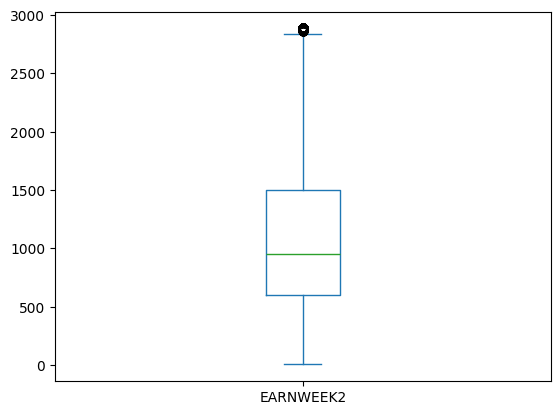

In [17]:
df_clean['EARNWEEK2'].quantile([0,.25,.5,.75,1])
#Box plot code
df_clean['EARNWEEK2'].plot(kind='box')

In [21]:
earn = df_clean['EARNWEEK2']

tukey_summary = {
    "Minimum": earn.min(),
    "Q1 (25%)": earn.quantile(0.25),
    "Median (50%)": earn.median(),
    "Q3 (75%)": earn.quantile(0.75),
    "Maximum": earn.max()
}
tukey_summary

{'Minimum': 4.0,
 'Q1 (25%)': np.float64(600.0),
 'Median (50%)': 948.0,
 'Q3 (75%)': np.float64(1500.0),
 'Maximum': 2885.0}

In [22]:
mean_earn = earn.mean()
median_earn = earn.median()
std_earn = earn.std()

mean_earn, median_earn, std_earn

(np.float64(1141.3089773456488), 948.0, 738.7359185288838)

The Tukey five-number summary provides a view of the center, spread and overall shape of teh earnigns distribution. This summary helps identify possible skewness of the data. In this dataset, the median weekly earnings are $948, and the range extends from 600 to 1500, indicating substantial variation in earnings.

The standard deviation measures the average distance of the data values from the mean, at 738.74 for this data set. Unlike the quartile boundaries of a Tukey summary the standard deviation gives us sensitivity to density and outliers.

# **Part B: Create Education-Based Subsets**

In [26]:
new_df=df_wage[df_wage['education']=="Bachelor's"].copy()

In [29]:
# Students with Bachelor's degrees
college = df_wage[df_wage['education'] == "Bachelor's"]

# Students with Master's degrees
grad = df_wage[df_wage['education'] == "Master's"]

# Display number of observations in each DataFrame
print("Number of Bachelor's students:", len(college))
print("Number of Master's students:", len(grad))

Number of Bachelor's students: 94154
Number of Master's students: 200910


In [31]:
df_wage['education'].value_counts()

,count
education,
Some College,270185
NIU / Child,227870
Master's,200910
Associate's,154542
Graduate / Professional,119275
Less than HS,116133
Bachelor's,94154
High School,15803


Group filtering logic - Bachelor's degree group was filtered to incldue only rows where the education colun exactly matches the string "Bachelor's". The same logic was applied for the Master's Degree Group.

The second data frame provdied the following number of observations aligning with the value counts of Bachelor's students being 94,154 and Master's students to be 200,910

# **Part C: Compare Earnings Distributions**


In [55]:
# Apply cleaning filters to df_wage and then select Bachelor's data
filtered_df = df_wage[(df_wage['UHRSWORKT'].between(1,80)) & (df_wage['AGE']>=18)].copy()
filtered_df.loc[filtered_df['EARNWEEK2']>=99999,'EARNWEEK2']=pd.NA
filtered_df.loc[filtered_df['EARNWEEK2']<1,'EARNWEEK2']=pd.NA

bachelors_data = filtered_df[filtered_df['education'] == "Bachelor's"]

# 2. Compute Mean, Median, and Mode for weekly earnings
mean_earn = bachelors_data['EARNWEEK2'].mean()
median_earn = bachelors_data['EARNWEEK2'].median()
mode_earn = bachelors_data['EARNWEEK2'].mode().iloc[0]  # .iloc[0] gets the most frequent value

# 3. Print the results clearly
print("=== Bachelor's Degree Earnings Statistics ===")
print(f"Mean Weekly Earnings:   ${mean_earn:.2f}")
print(f"Median Weekly Earnings: ${median_earn:.2f}")
print(f"Mode Weekly Earnings:   ${mode_earn:.2f}")

=== Bachelor's Degree Earnings Statistics ===
Mean Weekly Earnings:   $1009.38
Median Weekly Earnings: $880.00
Mode Weekly Earnings:   $1000.00


In [57]:
# 1. Apply cleaning filters to df_wage and then select Master's data
filtered_df_masters = df_wage[(df_wage['UHRSWORKT'].between(1,80)) & (df_wage['AGE']>=18)].copy()
filtered_df_masters.loc[filtered_df_masters['EARNWEEK2']>=99999,'EARNWEEK2']=pd.NA
filtered_df_masters.loc[filtered_df_masters['EARNWEEK2']<1,'EARNWEEK2']=pd.NA

masters_data = filtered_df_masters[filtered_df_masters['education'] == "Master's"]

# 2. Compute Mean, Median, and Mode for weekly earnings
mean_earn = masters_data['EARNWEEK2'].mean()
median_earn = masters_data['EARNWEEK2'].median()
mode_earn = masters_data['EARNWEEK2'].mode().iloc[0]  # Gets the primary mode

# 3. Print the results clearly
print("=== Master's Degree Earnings Statistics ===")
print(f"Mean Weekly Earnings:   ${mean_earn:.2f}")
print(f"Median Weekly Earnings: ${median_earn:.2f}")
print(f"Mode Weekly Earnings:   ${mode_earn:.2f}")

=== Master's Degree Earnings Statistics ===
Mean Weekly Earnings:   $1407.61
Median Weekly Earnings: $1250.00
Mode Weekly Earnings:   $2884.61


In [70]:
# 1. Apply cleaning filters to df_wage and then select Bachelor's data
# This ensures that EARNWEEK2 values for Bachelor's degrees are not incorrectly set to NA by previous filters.
filtered_df_bachelors_tukey = df_wage[(df_wage['UHRSWORKT'].between(1,80)) & (df_wage['AGE']>=18)].copy()
filtered_df_bachelors_tukey.loc[filtered_df_bachelors_tukey['EARNWEEK2']>=99999,'EARNWEEK2']=pd.NA
filtered_df_bachelors_tukey.loc[filtered_df_bachelors_tukey['EARNWEEK2']<1,'EARNWEEK2']=pd.NA

# Filter for Bachelor's degree holders and select their EARNWEEK2 values
earn = filtered_df_bachelors_tukey[filtered_df_bachelors_tukey['education'] == "Bachelor's"]['EARNWEEK2']

tukey_summary = {
    "Minimum": earn.min(),
    "Q1 (25%)": earn.quantile(0.25),
    "Median (50%)": earn.median(),
    "Q3 (75%)": earn.quantile(0.75),
    "Maximum": earn.max()
}
tukey_summary

{'Minimum': 4.0,
 'Q1 (25%)': np.float64(600.0),
 'Median (50%)': 880.0,
 'Q3 (75%)': np.float64(1260.0),
 'Maximum': 2885.0}

In [86]:
filtered_df_masters_tukey = df_wage[(df_wage['UHRSWORKT'].between(1,80)) & (df_wage['AGE']>=18)].copy()
filtered_df_masters_tukey.loc[filtered_df_masters_tukey['EARNWEEK2']>=99999,'EARNWEEK2']=pd.NA
filtered_df_masters_tukey.loc[filtered_df_masters_tukey['EARNWEEK2']<1,'EARNWEEK2']=pd.NA

earn_masters = filtered_df_masters_tukey[filtered_df_masters_tukey['education'] == "Master's"]['EARNWEEK2']

tukey_summary_masters = {
    "Minimum": earn_masters.min(),
    "Q1 (25%)": earn_masters.quantile(0.25),
    "Median (50%)": earn_masters.median(),
    "Q3 (75%)": earn_masters.quantile(0.75),
    "Maximum": earn_masters.max()
}
tukey_summary_masters

{'Minimum': 4.0,
 'Q1 (25%)': np.float64(800.0),
 'Median (50%)': 1250.0,
 'Q3 (75%)': np.float64(1920.0),
 'Maximum': 2885.0}

In [91]:
import matplotlib.pyplot as plt

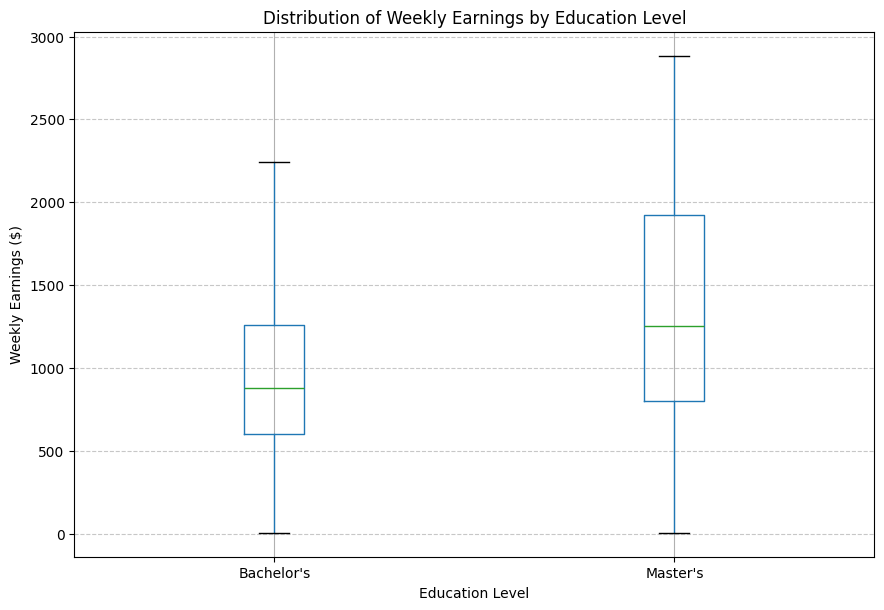

In [99]:
# From the kernel state, filtered_df_common already has the initial cleaning applied
# Now filter it to include only 'Bachelor\'s' and 'Master\'s'
df_for_comparison_plot = filtered_df_common[
    filtered_df_common['education'].isin(["Bachelor's", "Master's"])
].dropna(subset=['EARNWEEK2']) # Ensure no NA earnings for plotting

# Generate the box plot
plt.figure(figsize=(10, 7))
df_for_comparison_plot.boxplot(column='EARNWEEK2', by='education', showfliers=False, ax=plt.gca())
plt.title('Distribution of Weekly Earnings by Education Level')
plt.ylabel('Weekly Earnings ($)')
plt.xlabel('Education Level')
plt.suptitle('') # Remove the default suptitle created by pandas boxplot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

When evaluating the weekly earnings, EARNWEEK2, between the two education groups, differences are apparent in both central tendency and dispersion. In terms of typical earnings, the median and mean values are higher for the Master's degree group compared to the Bachelor's degree group, indicating a higher center of distribution for those with advanced degrees.The overall spread and variability also differ between the groups. The Master's degree group exhibits a larger standard deviation and a wider Interquartile Range than the Bachelor's degree group, pointing to a broader distribution of weekly earnings among individuals with Master's degrees.

This pattern contrasts with the standard distribution of hours worked (UHRSWORKT) observed in class. While weekly earnings show a dynamic range, substantial variation, and a distinct step upward between the Bachelor's and Master's groups, the typical Tukey five-number summary for hours worked generally shows an incredibly tight concentration around a standard 40-hour workweek. There is a cluster heavily right at or clsoe to 40 hours, highlighting that while earnings vary widely across education levels, the reported time spent working remains highly uniform.

# **Part D: Correlation Between Hours and Earnings**

In [94]:
df_corr = df_clean.dropna(subset=['UHRSWORKT', 'EARNWEEK2'])
df_corr[['UHRSWORKT', 'EARNWEEK2']].corr()



,UHRSWORKT,EARNWEEK2
UHRSWORKT,1.000000,0.466906
EARNWEEK2,0.466906,1.000000


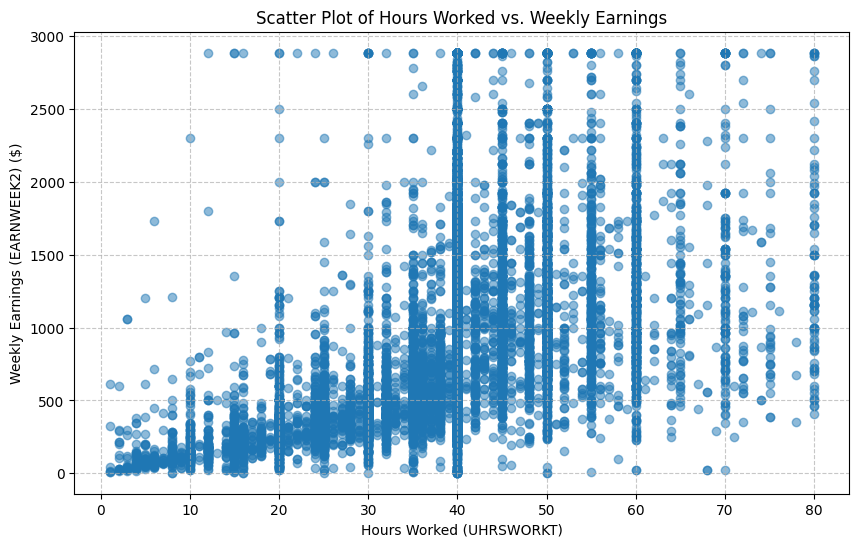

In [98]:
plt.figure(figsize=(10, 6))
plt.scatter(df_corr['UHRSWORKT'], df_corr['EARNWEEK2'], alpha=0.5)
plt.title('Scatter Plot of Hours Worked vs. Weekly Earnings')
plt.xlabel('Hours Worked (UHRSWORKT)')
plt.ylabel('Weekly Earnings (EARNWEEK2) ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Based on the corrected scatter plot, there is a positive relationship between the usual hours worked UHRSWORKT and weekly earnings EARNWEEK2. This means that as the number of hours worked increases, the upper bounds of weekly earnings generally trend upward. However, the overall strength of this linear relationship is weak to moderate.

The usual hours worked do not appear to explain a substantial portion of the total variation in weekly earnings. An example of this is when you look closely at the standard 40-hour workweek column, earnings are not tightly clustered around a single point; instead, they span the entire vertical range of the chart from near 0 up to the maximum cap of nearly 3,000.

Because individuals working identical hours experience vastly different levels of compensation, underlying factors other than time spent on the clock—such as industry sector, job role, specific education level, and years of experience—account for the vast majority of the variance in weekly earnings.

## Part E: **Reflection**

I believe the median was the most useful descriptive statistic for comparing earings across education groups. The median gives us the center of the distribution whereas the mean gets pulled upward/downward by outliers. In one of the datapoints above we see teh median clearly showing a distinct step upware in typical weekly compensation for the Master's degree group 880 compared to the Bachelor's degree group of 1250.